This one is an update to the previous script 'BTMS eval vs Power generation.ipynb', which contains an error in its modeling and solving process. 

The previous script adapts a two-step strategy to locate the temperature distribution (coolant first, then battery). 

This time I decide to locate the temperature distribution for battery and coolant simultaneously. 



In [1]:
# read the power generation profile per time step

import csv
import os
import sys
import numpy as np
import pandas as pd

# data file name

file_name = os.path.join(os.getcwd(), 'data', 'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx')

# read the data from the csv file
time_steps = []
power_generation = []

df = pd.read_excel(file_name, sheet_name='Sheet1')

# extract the power generation data 
power_generation_data = df['Qbat(W)'].values[1:]


In [2]:
import numpy as np
from io import StringIO

types = (
    ('avg', 'MD05E070210A2  data_aircooling BTMS_temperature_avg.out'),
    ('max', 'MD05E070211A2  data_aircooling BTMS_temperature_max.out'),
    ('min', 'MD05E070212A2  data_aircooling BTMS_temperature_min.out')
)

temperature_cfd_data = {}  # dictionary to store CFD temperature data for each type

for t, file_name in types:
    file_name_cfd = os.path.join(os.getcwd(), 'data', file_name)

    # Parse the Fluent report file: skip header lines starting with '"' and '(', read space-separated columns
    with open(file_name_cfd, 'r') as f:
        lines = [line.strip() for line in f if line.strip() and not line.strip().startswith('"') and not line.strip().startswith('(')]

    data_cfd = np.loadtxt(StringIO('\n'.join(lines)))
    time_step_cfd = data_cfd[:, 0].astype(int)
    flow_time_cfd = data_cfd[:, 1]
    report_def_0_cfd = data_cfd[:, 2]  # avg battery temperature from CFD [K]
    
    temperature_cfd_data[t] = (flow_time_cfd, report_def_0_cfd)


In [3]:
dt = 1 # time step in seconds

# battery parameters foundin [[parkpark2025RefinedAircooled]]
T_bat_init = 25 # initial battery temperature in Celsius
cp_bat = 830 # specific heat capacity of the battery in J/(kg°C) 
m_bat = 48e-3 # mass of the battery in kg
D_bat = 18e-3 # diameter of the battery in meters
H_bat = 65e-3 # height of the battery in meters
A_battery = np.pi * D_bat * H_bat # surface area of the battery in m^2

num_time_steps = len(power_generation_data)
# calculate the battery temperature over time
T_bat = np.zeros(num_time_steps)
T_bat[0] = T_bat_init

for i in range(1, num_time_steps):
    # calculate the temperature change based on the power generation and battery parameters
    dT = (power_generation_data[i-1] * dt) / (m_bat * cp_bat)
    T_bat[i] = T_bat[i-1] + dT      


In [4]:
# Žukauskas Nusellet correlation for natural convection from a horizontal cylinder
def zukauskas_nusellet(Re, Pr, *args):
    '''
    Calculate the Nusselt number for natural convection from a horizontal cylinder using the Žukauskas Nusellet correlation.
    Found eq. 19 in [[parkpark2025RefinedAircooled]].
    Parameters:
    Re: Reynolds number
    Pr: Prandtl number
    args: additional arguments for the correlation (e.g., correction factor)
    Returns:
    Nu: Nusselt number

    '''
    eps = args[0]  # correction factor for the Nusselt number
    Pr_s = args[1]  # Prandtl number at the surface temperature

    if Re > 0 and Re < 500:
       Nu = eps * 1.04 * (Re ** 0.4) * (Pr ** 0.36) * (Pr / Pr_s) ** 0.25
    elif Re >= 500 and Re < 1000:
        Nu = eps * 0.71 * (Re ** 0.5) * (Pr ** 0.36) * (Pr / Pr_s) ** 0.25
    elif Re >= 1000 and Re < 2e5:
        Nu = eps * 0.193 * (Re ** 0.62) * (Pr ** 0.36) * (Pr / Pr_s) ** 0.25
    else:
        Nu = eps * 0.027 * (Re ** 0.8) * (Pr ** 0.36) * (Pr / Pr_s) ** 0.25
        
    return Nu

In [5]:
# select the correction factor based on battery arrangement (in terms of number of columns) and Reynolds number
def select_correction_factor(no_col, Re):
    """
    Return correction factor eps for tube bank/cell-column arrangements.

    Data source (from your referenced table):
    - 1e2 < Re < 1e3
    - Re > 1e3
    with columns 1..9.

    Parameters
    ----------
    no_col : int
        Number of columns in the battery arrangement (1 to 9).
    Re : float
        Reynolds number based on battery diameter.

    Returns
    -------
    float
        Correction factor eps.
    """
    if no_col < 1:
        raise ValueError("no_col must be >= 1")

    # Clamp to available tabulated range [1, 9].
    col = int(round(no_col))
    col = max(1, min(9, col))
    idx = col - 1

    eps_1e2_to_1e3 = [0.832, 0.874, 0.914, 0.939, 0.955, 0.963, 0.970, 0.976, 0.980]
    eps_gt_1e3 = [0.619, 0.758, 0.840, 0.897, 0.923, 0.942, 0.954, 0.965, 0.971]

    # Piecewise selection with linear blending across the transition region.
    if Re <= 1e2:
        eps = eps_1e2_to_1e3[idx]
    elif Re < 1e3:
        eps = eps_1e2_to_1e3[idx]
    elif Re > 1e3:
        eps = eps_gt_1e3[idx]
    else:  # Re == 1e3
        eps = 0.5 * (eps_1e2_to_1e3[idx] + eps_gt_1e3[idx])

    return eps

In [6]:
# solve coolant temperture distribution using a 1D finite difference approach along the flow direction

import scipy.optimize as opt
import copy
import CoolProp.CoolProp as CP

def cal_power_residual(T_dist, args):  
    
    num_seg = args.get("num_seg")
    T_cool_pre = args.get("T_cool_pre")
    T_bat_pre = args.get("T_bat_pre")
    u_cool = args.get("u_cool")
    p_cool = args.get("p_cool")
    fluid_cool = args.get("fluid_cool")
    A_battery = args.get("A_battery")
    A_cool = args.get("A_cool")
    D_bat = args.get("D_bat")
    T_cool_in = args.get("T_cool_in")
    is_cool = args.get("is_cool")
    htc_cool = args.get("htc_cool") # use constant heat transfer coefficient for simplicity; adjust as needed
    cp_cool = args.get("cp_cool") # use constant specific heat capacity for simplicity; adjust as needed
    rho_cool = args.get("rho_cool") # use constant density for simplicity; adjust as needed
    Q_gen = args.get("Q_gen")
    debug = args.get("debug", False)
    
    # The T_dist variable contains the temperature for both coolant and battery for each segment along the flow path
    
    T_cool = T_dist[0:num_seg]  # the first half: coolant temperature distribution along the flow path, this is the variable we want to solve for in the optimization solver
    T_bat = T_dist[num_seg:] # the second half   
         
    residual = np.zeros(num_seg)  # initialize residual array for each segment

    for i in range(num_seg): 

        # calculate the Prandtl number at the surface temperature (battery temperature) and the inlet coolant temperature for this segment
    
        T_cool_seg_in = T_cool_in if i == 0 else T_cool[i-1]  # inlet coolant temperature for this segment
        
        T_cool_bar = (T_cool_seg_in + T_cool[i]) / 2  # average coolant temperature for this segment        
        # T_cool_bar = T_cool_seg_in 
        # convective heat transfer on the cooling side
        if not is_cool:
            Q_cool_HT = 0
          
        else:          
            Q_cool_HT = htc_cool[i] * A_battery * (T_bat[i-1] - T_cool_bar)  # use the average temperature between the current and inlet coolant temperature for heat transfer calculation

        dT_bat = T_bat[i] - T_bat_pre[i]  # change in battery temperature 
        
        if debug:
            print(f"Segment {i}: Q_gen = {Q_gen}, Q_cool_HT = {Q_cool_HT}, dT_bat = {dT_bat}; T_bat_cur = {T_bat}, T_cool_bar = {T_cool_bar}")  # debug print for power generation, cooling power, and battery temperature change for this segment

        Q_bat = dT_bat * m_bat * cp_bat / dt  # heat input rate related to temperature change
        
        res_bat = abs(Q_gen - Q_bat - Q_cool_HT) # residual for the battery energy balance, should be close to zero when the battery temperature distribution is correct        
          
        Q_cool_change = u_cool * A_cool * rho_cool * cp_cool * (T_cool[i] - T_cool_seg_in)  # calculate the power transfer to the coolant based on the current guess of the coolant temperature distribution for this segment, using a constant specific heat capacity and temperature change for the coolant for simplicity; adjust as needed
        
        # # detemrine the power transfer based on the change in enthalpy of the coolant across this segment; This calculation is more accurate but more computationally expensive than using a constant specific heat capacity and temperature change for the coolant; adjust as needed
        # h_cool_in = CP.PropsSI('H', 'T', T_cool_seg_in+273.15, 'P', p_cool, fluid_cool)  # enthalpy of the coolant at the inlet temperature for this segment
        # h_cool_out = CP.PropsSI('H', 'T', T_cool[i]+273.15, 'P', p_cool, fluid_cool)  # enthalpy of the coolant at the outlet temperature for this segment
        # Q_cool_change = u_cool * A_cool * rho_cool * (h_cool_out - h_cool_in)  # calculate the power transfer to the coolant based on the change in enthalpy of the coolant across this segment
        
        res_cool = abs(Q_cool_HT - Q_cool_change) # residual for the coolant energy balance, should be close to zero when the coolant temperature distribution is correct
                
        # calculate the residual between the input power and the power received by the coolant
        residual[i]= res_bat**2 + res_cool**2 # should be close to zero when the coolant temperature distribution is correct
    
    if debug:
        print(f"heat transfer coefficient h_cool for this segment {i}: {htc_cool}")  # debug print for the calculated heat transfer coefficient for this segment
        print(f"Current coolant temperatures: {T_cool}")  # debug print for the current coolant temperature distribution in this iteration
        print(f"Current residual: {residual}")  # debug print for the current residual in this iteration     
    return residual

def solve_coolant_temperature_distribution(args, tol=1e-6, maxiter=1000, debug=False):
    
    T_bat_pre = args.get("T_bat_pre")
    num_seg = len(T_bat_pre)    
    T_cool_in = args.get("T_cool_in")
    T_cool_out = args.get("T_cool_out") # expected outlet coolant temperature

    T_cool = np.linspace(T_cool_in, T_cool_out, num_seg+1)[1:]  # initial guess for coolant temperature distribution (linear from inlet to outlet temperature)
    
    T_bat = copy.deepcopy(T_bat_pre)  # use the previous battery temperature distribution as the initial guess for the battery temperature distribution in the optimization solver, this will be updated in each iteration of the optimization solver based on the current guess of the coolant temperature distribution
    
    T_dist = np.concatenate((T_cool, T_bat))  # combine coolant and battery temperature distributions into a single array for the optimization solver
    
    print(f"Initial guess for {len(T_cool)} coolant temperatures along the flow path: {T_cool}")  # debug print for the initial guess of the coolant temperature distribution
    
    # T_cool_init = np.insert(T_cool_init, 0, T_cool_in)  # insert inlet temperature at the beginning of the coolant temperature array

    num_solutions = len(T_dist)
    upper_bound = np.ones(num_solutions) * (T_cool_in + 300) # set an upper bound for the coolant temperature distribution for the optimization solver, adjust as needed
    
    lower_bound = np.ones(num_solutions) * T_cool_in # set a lower bound for the coolant temperature distribution for the optimization solver, adjust as needed
    
    res = opt.least_squares(        
        cal_power_residual, 
        T_dist, 
        args=([args]), 
        method ='trf', 
        verbose=2,
        ftol=tol, max_nfev=maxiter,
        bounds=(lower_bound, upper_bound)
    )
    
    # output the battery temperature and coolant temperature distribution for debugging

    if debug:
        print("Optimization success:", res.success)
        print("Final residual:", res.fun)        
        print("Optimized coolant temperatures:", res.x)
    
    return res.x

In [ ]:

# Initial conditions and parameters

# V_air_nom = 241 # nominal air velocity in km/h for the cooling system (example value, adjust as needed)
# V_air = V_air_nom / 3.6 # convert nominal air velocity to m/s

V_air = 1.5 # example air velocity for testing (adjust as needed)
# V_air = [0.1 # air velocity in m/s 

T_air = 25 # ambient air temperature in Celsius
T_air_K = T_air + 273.15 # convert to Kelvin

p_air = 101325 # ambient air pressure in Pa

N_r, N_c = 16, 20 # number of rows and columns in the battery arrangement for a single module (example values, adjust as needed)

S_T = 1.25 * D_bat # spacing between battery rows in meters (example value, adjust as needed)

W_module = D_bat + (N_r - 1) * S_T # width of the battery module in meters (example calculation, adjust as needed)

A_air = W_module * H_bat # cross-sectional area of a single module of the air flow path in m^2

A_air_row = A_air / N_c # cross-sectional area of the air flow path for each row of batteries in m^2

fluid = 'Air'

t_cruise_start = 180 # time step when the cruise phase starts (example value, adjust as needed)
t_cruise_end = 1560 # time step when the cruise phase ends (example value, adjust as needed)


In [8]:
# calculate the battery temperature changes over the time steps based on the power generation and the cooling effect of the air flow

import CoolProp.CoolProp as CP

# Calculate the Prandtl number for air at ambient conditions
mu_air = CP.PropsSI('V', 'T', T_air_K, 'P', p_air, fluid) # dynamic viscosity of air in kg/(m·s)
rho_air = CP.PropsSI('D', 'T', T_air_K, 'P', p_air, fluid) # density of air in kg/m^3
cp_air = CP.PropsSI('C', 'T', T_air_K, 'P', p_air, fluid) # specific heat capacity of air in J/(kg·K)
k_air = CP.PropsSI('L', 'T', T_air_K, 'P', p_air, fluid) # thermal conductivity of air in W/(m·K)

Pr_air = cp_air * mu_air / k_air # Prandtl number for air


V_air_max = S_T / (S_T - D_bat) * V_air # maximum air velocity regarding the space compression

# Calculate the Reynolds number for the air flow over the battery
Re_air = (rho_air * V_air_max * D_bat) / mu_air

num_segment = N_c # number of segments for the finite difference method along the flow direction, adjust as needed
htc_seg = np.zeros(num_segment) # to store the convective heat transfer coefficient for each segment, adjust as needed
for i in range(num_segment):
    
    # calculate the Nusselt number using the Žukauskas Nusellet correlation
    eps = select_correction_factor(no_col=i+1, Re=Re_air)  # example with 1 column, adjust as needed
    Nu_air_seg = zukauskas_nusellet(Re_air, Pr_air, eps, Pr_air)

    # calculate the convective heat transfer coefficient for this segment
    htc_seg[i] = (Nu_air_seg * k_air) / D_bat # convective heat transfer coefficient in W/(m^2·K)

# battery temperature distribution with air cooling over time steps

T_bat_history = np.empty(num_time_steps, dtype=object) # initialize the battery temperature history for each segment as an empty list

T_air_history = np.empty(num_time_steps, dtype=object) # initialize the air temperature history for each segment as an empty list

Q_cool_history = np.empty(num_time_steps, dtype=object) # initialize the cooling power history for each segment as an empty list
Q_cool_history_fd_total = np.zeros(num_time_steps) # to store the cooling power history calculated based on the finite difference method for analysis

for i in range(num_time_steps):
    T_bat_history[i] = np.ones(num_segment) * T_bat_init # initialize the battery temperature history for each segment in the current time step as an empty array

    T_air_history[i] = np.ones(num_segment) * T_air # initialize the air temperature history for each segment in the current time step as an empty array
    
    Q_cool_history[i] = np.zeros(num_segment) # initialize the cooling power history for each segment in the current time step as an empty array
    
debug = False

t = 0 # initialize time variable

for i in range(1, num_time_steps):
    print(f"****** Time step {i}: t = {t} seconds ******")  # debug print for the current time step and time variable
    
    # solve for the coolant temperature distribution and battery temperature distribution
    # extract the current battery temperature distribution from the history
    
    T_bat_pre = T_bat_history[i-1] # battery temperature dist in the previous time step, use initial battery temperature as the first step. 
    
    T_cool_pre = T_air_history[i-1] # air temperature dist in the previous time step, use initial air temperature as the first step.
    # print T_bat_air_cur for debugging
    
    print(f"Time step {i}(before): T_bat = {T_bat_pre}")
    
    is_cooling = (t >= t_cruise_start) and (t <= t_cruise_end)  # determine if cooling is active based on the current time step
        
    args = {
        "T_bat_pre": T_bat_pre, 
        "T_cool_pre": T_cool_pre,
        "u_cool": V_air ,
        "p_cool": p_air,
        "fluid_cool": fluid,
        "A_battery": A_battery,
        "A_cool": A_air_row,
        "D_bat": D_bat,
        "num_seg": num_segment,
        "T_cool_in": T_air,
        "T_cool_out": T_air_out_0D[i], # use the calculated outlet air temperature for this time step as the expected outlet temperature for the optimization solver,
        "htc_cool": htc_seg, # use the calculated segment-wise convective heat transfer coefficient for the optimization solver, adjust as needed
        "cp_cool": cp_air, # use the calculated specific heat capacity of air for
        "rho_cool": rho_air, # use the calculated density of air for the optimization solver, adjust as needed
        "is_cool": is_cooling,
        "Q_gen": power_generation_data[i],
        "debug": debug
    }
  
    T_dist = solve_coolant_temperature_distribution(
        args,
        tol = 1e-3,
        maxiter = 1000,
        debug = debug
    )
    
    T_cool_air = T_dist[0:num_segment]  # the first half: coolant temperature distribution along the flow path, this is the variable we want to solve for in the optimization solver
    T_bat_cur = T_dist[num_segment:] # the second half: battery temperature distribution along the flow path, this is the variable we want to solve for in the optimization solver
    
    for j in range(num_segment):
        T_segment_in = T_air if j == 0 else T_cool_air[j-1]  # inlet temperature for this segment
        T_cool_avg = (T_segment_in + T_cool_air[j]) / 2  # average temperature for this segment
        Q_cool_segment = 0 # initialize cooling power for this segment
        
        if is_cooling and T_bat_cur[j] > T_cool_avg:  # calculate cooling power for this segment only when cooling is active and the battery temperature is higher than the average coolant temperature for this segment
            Q_cool_segment = htc_seg[j] * A_battery * (T_bat_cur[j] - T_cool_avg)  # cooling power for this segment
        Q_cool_history[i][j] += Q_cool_segment  # accumulate the cooling power for this time step
    
    Q_cool_history_fd_total[i] = np.sum(Q_cool_history[i]) # store the total cooling power for this time step calculated based on the finite difference method for analysis
    
    print(f"Time step {i}(after): T_cool_air = {T_cool_air}")  # debug print for the solved coolant temperature distribution
    print(f"Time step {i}(after): T_bat_cur = {T_bat_cur}")  # debug print for the solved battery temperature distribution 
    
    # save temperature history for this time step
    T_bat_history[i] = T_bat_cur
    T_air_history[i] = T_cool_air    
    
    t += dt


****** Time step 1: t = 0 seconds ******
Time step 1(before): T_bat = [25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25.
 25. 25.]


NameError: name 'A_air_row' is not defined

In [7]:

# Initial conditions and parameters

# V_air_nom = 241 # nominal air velocity in km/h for the cooling system (example value, adjust as needed)
# V_air = V_air_nom / 3.6 # convert nominal air velocity to m/s

V_air = 1.5 # example air velocity for testing (adjust as needed)
# V_air = [0.1 # air velocity in m/s 

T_air = 25 # ambient air temperature in Celsius
T_air_K = T_air + 273.15 # convert to Kelvin

p_air = 101325 # ambient air pressure in Pa

N_r, N_c = 16, 20 # number of rows and columns in the battery arrangement for a single module (example values, adjust as needed)

S_T = 1.25 * D_bat # spacing between battery rows in meters (example value, adjust as needed)

W_module = D_bat + (N_r - 1) * S_T # width of the battery module in meters (example calculation, adjust as needed)

A_air = W_module * H_bat # cross-sectional area of a single module of the air flow path in m^2

A_air_row = A_air / N_r # cross-sectional area of the air flow path for each row of the battery arrangement in m^2

fluid = 'Air'

t_cruise_start = 180 # time step when the cruise phase starts (example value, adjust as needed)
t_cruise_end = 1560 # time step when the cruise phase ends (example value, adjust as needed)

num_time_steps = len(power_generation_data) # number of time steps based on the power generation data


In [12]:
# calculate the battery temperature profile when introducing an air cooling system
import CoolProp.CoolProp as CP
# Calculate the Prandtl number for air at ambient conditions
mu_air = CP.PropsSI('V', 'T', T_air_K, 'P', p_air, fluid) # dynamic viscosity of air in kg/(m·s)
rho_air = CP.PropsSI('D', 'T', T_air_K, 'P', p_air, fluid) # density of air in kg/m^3
cp_air = CP.PropsSI('C', 'T', T_air_K, 'P', p_air, fluid) # specific heat capacity of air in J/(kg·K)
k_air = CP.PropsSI('L', 'T', T_air_K, 'P', p_air, fluid) # thermal conductivity of air in W/(m·K)
Pr_air = cp_air * mu_air / k_air # Prandtl number for air


V_air_max = S_T / (S_T - D_bat) * V_air # maximum air velocity regarding the space compression

# Calculate the Reynolds number for the air flow over the battery
Re_air = (rho_air * V_air_max * D_bat) / mu_air

eps = select_correction_factor(no_col=9, Re=Re_air) # select the correction factor for a single column arrangement and the calculated Reynolds number
Nu_air = zukauskas_nusellet(Re_air, Pr_air, eps, Pr_air) # calculate the Nusselt number using the Žukauskas Nusellet correlation

htc_air = (Nu_air * k_air) / D_bat # convective heat transfer coefficient in W/(m^2·K)
# calculate the cooling power provided by the air cooling system

# battery temperature under air cooling
T_bat_0D = np.zeros(num_time_steps)
T_bat_0D[0] = T_bat_init
T_air_out_0D = np.zeros(num_time_steps) # to store the outlet air temperature for analysis
T_air_out_0D[0] = T_air # initial outlet air temperature is the same as inlet air temperature
t = 0 # initialize time variable

Q_cool_profile_0D = np.zeros(num_time_steps) # to store the cooling power profile for analysis

for i in range(1, num_time_steps):
    
    # enable the air cooling in the cruise phase only 
    T_air_in = T_air 
    Q_cool_HT = 0 # initialize cooling power for this time step
    
    if t < t_cruise_start or t > t_cruise_end:
        Q_cool_HT = 0    
        T_air_out_0D[i] = T_air # outlet air temperature is the same as inlet air temperature when no cooling occurs
    
    else:    
        # calculate the Prandtl number at the battery surface temperature

        T_air_avg = (T_air_out_0D[i-1] + T_air_in) / 2  # average air temperature for this time step
        
        Q_cool_HT = htc_air * A_battery * N_c * N_r * (T_bat_0D[i-1] - T_air_avg) # cooling power in W
        # h_air_in = CP.PropsSI('H', 'T', T_air_in + 273.15, 'P', p_air, fluid) # enthalpy of air at inlet conditions in J/kg
        # h_air_out = h_air_in + Q_cool_air * N_c * N_r / (rho_air * V_air * A_air) # enthalpy of air at outlet conditions in J/kg
        # T_air_out_0D[i] = CP.PropsSI('T', 'H', h_air_out, 'P', p_air, fluid) - 273.15 # convert to Celsius and store the outlet air temperature for analysis
        dT_air = Q_cool_HT / (rho_air * V_air * A_air * cp_air) # calculate the temperature change of the air based on the cooling power and the mass flow rate of the air
        T_air_out_0D[i] = T_air_in + dT_air 
        
        print(f"Time step {i}: Q_cool_air = {Q_cool_HT:.2f} W, dT_air = {dT_air:.8f} °C, dT_out = {T_air_out_0D[i] - T_air_out_0D[i-1]:.8f} °C")  # debug print for cooling power and air enthalpy change for this time step

    Q_cool_profile_0D[i] = Q_cool_HT # store the cooling power for analysis
    # calculate the temperature change based on the power generation, battery parameters, and air cooling
    dT = (power_generation_data[i-1] * N_c * N_r - Q_cool_HT) * dt / (m_bat * N_c * N_r * cp_bat)
    T_bat_0D[i] = T_bat_0D[i-1] + dT
    
    t = t + dt # update time variable


Time step 181: Q_cool_air = 315.56 W, dT_air = 7.63897419 °C, dT_out = 7.63897419 °C
Time step 182: Q_cool_air = 14.68 W, dT_air = 0.35536925 °C, dT_out = -7.28360494 °C
Time step 183: Q_cool_air = 300.72 W, dT_air = 7.27980384 °C, dT_out = 6.92443458 °C
Time step 184: Q_cool_air = 27.95 W, dT_air = 0.67653766 °C, dT_out = -6.60326618 °C
Time step 185: Q_cool_air = 287.23 W, dT_air = 6.95322676 °C, dT_out = 6.27668910 °C
Time step 186: Q_cool_air = 39.93 W, dT_air = 0.96670828 °C, dT_out = -5.98651848 °C
Time step 187: Q_cool_air = 274.96 W, dT_air = 6.65620253 °C, dT_out = 5.68949425 °C
Time step 188: Q_cool_air = 50.76 W, dT_air = 1.22878483 °C, dT_out = -5.42741769 °C
Time step 189: Q_cool_air = 263.80 W, dT_air = 6.38597494 °C, dT_out = 5.15719011 °C
Time step 190: Q_cool_air = 60.53 W, dT_air = 1.46539965 °C, dT_out = -4.92057530 °C
Time step 191: Q_cool_air = 253.64 W, dT_air = 6.14004549 °C, dT_out = 4.67464585 °C
Time step 192: Q_cool_air = 69.36 W, dT_air = 1.67893904 °C, dT_o

<Figure size 1000x600 with 0 Axes>

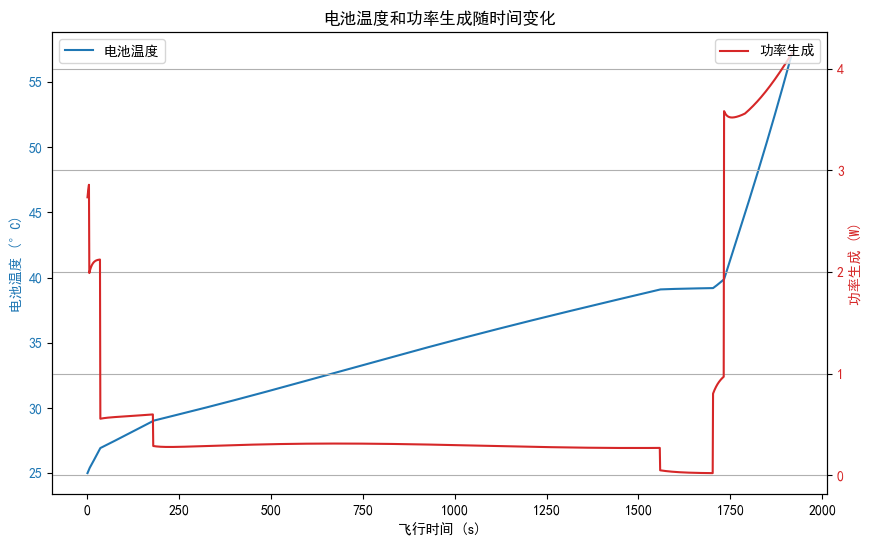

In [10]:
# in this part, plot the battery temperature profile over time steps with and without air cooling, and the power generation profile for analysis

import matplotlib.pyplot as plt
# Add support to display Chinese characters in the plot
plt.rcParams['font.sans-serif'] = ['SimHei']  # Use SimHei font for Chinese characters
plt.rcParams['axes.unicode_minus'] = False  # Ensure that

plt.figure(figsize=(10, 6))

time_array = np.arange(len(power_generation_data)) * dt  # create an array of time values corresponding to the time steps

# remove the last time step which contains an error
time_array = time_array[:-1]
T_bat_plot = T_bat[:-1]
power_plot = power_generation_data[:-1]  

# plot two y-axes for battery temperature and power generation
fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('飞行时间 (s)')
ax1.set_ylabel('电池温度 (°C)', color=color)
ax1.plot(time_array, T_bat_plot, label='电池温度', color=color, linestyle='-')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')    
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('功率生成 (W)', color=color)  # we already handled the x-label with ax1
ax2.plot(time_array, power_generation_data[:-1], label='功率生成', color=color, linestyle='-')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')
plt.title('电池温度和功率生成随时间变化')
plt.grid()
plt.show()

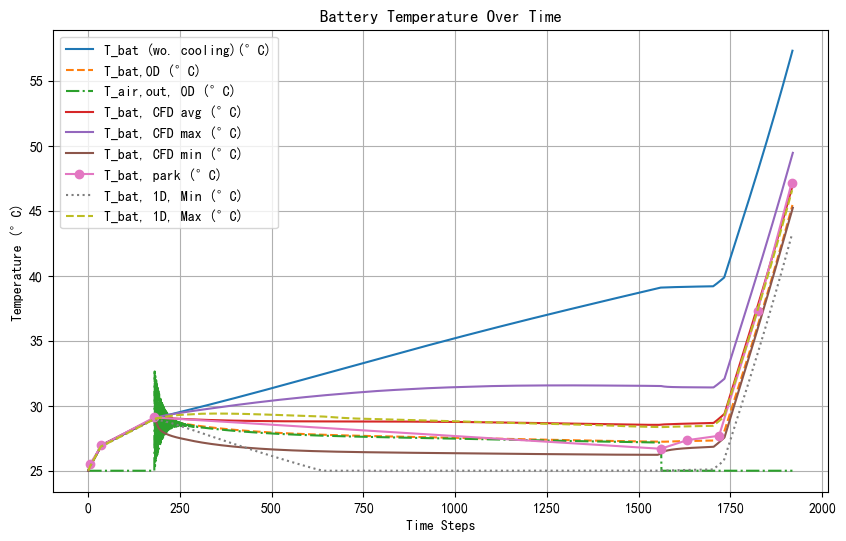

In [20]:
# plot the battery temperature over time
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(T_bat, label='T_bat (wo. cooling)(°C)')
# plot the battery temperature under air cooling as a dashed line
plt.plot(T_bat_0D, label='T_bat,0D (°C)', linestyle='--')

# plot the air outlet temperature profile for analysis
plt.plot(T_air_out_0D, label='T_air,out, 0D (°C)', linestyle='-.') # convert to Celsius for plotting

# plot the CFD temperature data for comparison
for t, (flow_time_cfd, report_def_0_cfd) in temperature_cfd_data.items():
    plt.plot(flow_time_cfd, report_def_0_cfd - 273.15, label=f'T_bat, CFD {t} (°C)') # convert CFD temperature from K to °C for plotting   

# plot the band between the max and min CFD temperatures to visualize the range of CFD predictions
# plt.fill_between(temperature_cfd_data['min'][0], temperature_cfd_data['min'][1] - 273.15, temperature_cfd_data['max'][1] - 273.15, color='gray', alpha=0.3, label='CFD Temperature Range (°C)') # convert CFD temperatures from K to °C for plotting

# plot the experimental temperature data from Park's paper for comparison
t_park = [6, 36, 180, 1560, 1632, 1719, 1824, 1917]
T_park = [298.7, 300.1, 302.25, 299.84, 300.5, 300.84, 310.45, 320.31] # Park's experimental temperature data in Kelvin

plt.plot(t_park, np.array(T_park) - 273.15, label='T_bat, park (°C)', marker='o') # convert Park's temperature from K to °C for plotting

# plot the battery temperature calculated using the one-dimensional finite difference method for the air cooling case as a dashed line
T_bat_air_fd_min = np.array([T_bat_history[i][0] for i in range(num_time_steps)]) # minimum battery temperature across segments at each time step

T_bat_air_fd_max = np.array([T_bat_history[i][-1] for i in range(num_time_steps)]) # maximum battery temperature across segments at each time step

plt.plot(T_bat_air_fd_min[:-1], label='T_bat, 1D, Min (°C)', linestyle=':') # plot the minimum battery temperature across segments as a dotted line
plt.plot(T_bat_air_fd_max[:-1], label='T_bat, 1D, Max (°C)', linestyle='--') # plot the maximum battery temperature across segments as a dotted line
# plt.fill_between(range(len(T_bat_air_0D)), T_bat_air_fd_min, T_bat_air_fd_max, color='blue', alpha=0.1, label='Battery Temperature Range with Air Cooling (1D FD) (°C)') # fill the area between the minimum and maximum battery temperatures across segments to visualize the range of temperatures predicted by the 1D finite difference method

T_cool_air_fd = np.array([T_air_history[i][1] for i in range(num_time_steps)]) # coolant temperature at the second segment (example) across time steps for analysis
T_cool_air_fd_out = np.array([T_air_history[i][-1] for i in range(num_time_steps)]) # coolant temperature at the last segment (outlet) across time steps for analysis


plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.title('Battery Temperature Over Time')
plt.legend()
plt.grid()
plt.show()

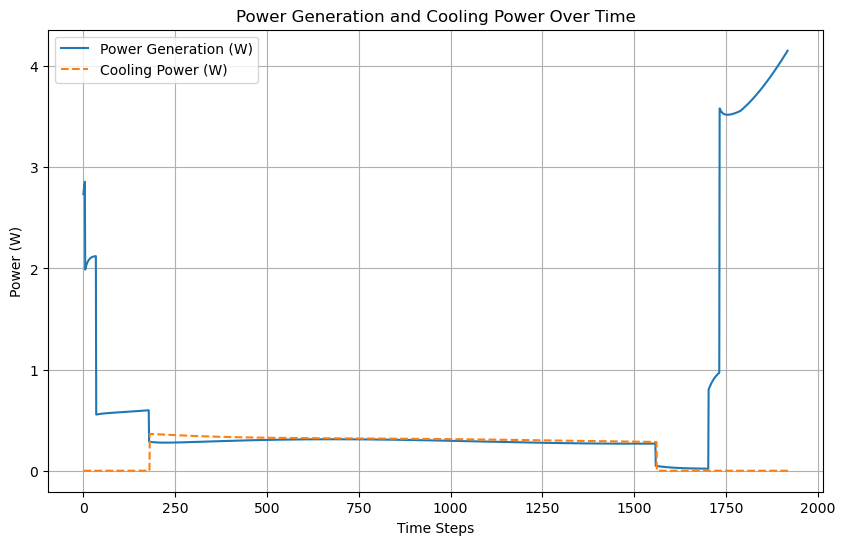

In [124]:
# plot the power generation and cooling power profiles
plt.figure(figsize=(10, 6))
plt.plot(power_generation_data, label='Power Generation (W)')
plt.plot(Q_cool_air_profile, label='Cooling Power (W)', linestyle='--')
plt.xlabel('Time Steps')
plt.ylabel('Power (W)')
plt.title('Power Generation and Cooling Power Over Time')
plt.legend()
plt.grid()
plt.show()